# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C_dec'

data_dir =f'/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_bmra/blca_publication_OUTPUT_bmra_{cell_line}_aug/'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_{cell_line}/"

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(14, 124)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,TGFBR/SMAD_V11,TGFBR/SMAD_V12,TGFBR/SMAD_V13,TGFBR/SMAD_V14,TGFBR/SMAD_V15,TGFBR/SMAD_V16,TGFBR/SMAD_V17,TGFBR/SMAD_V18,TGFBR/SMAD_V19,TGFBR/SMAD_V20
Androgen,-0.052671,-0.009376,0.001865,-0.039650,0.001388,0.020341,0.004221,0.016370,0.020991,0.036097,...,0.013393,0.005400,-0.001662,0.001754,0.000742,0.008326,-0.003464,0.009006,0.003900,0.022117
CDK1_2,-0.903266,-0.682124,0.060050,-0.122889,0.112326,-0.308019,-0.005712,-0.242859,0.119589,0.041190,...,-0.442907,-0.407670,-0.373295,-0.390382,-0.361692,-0.376317,-0.368947,-0.406712,-0.404733,-0.438361
CDK4_6,-0.092655,-0.211609,-0.265543,-0.141419,-0.163855,-0.102997,-0.017022,-0.028904,-0.218487,-0.010460,...,0.197639,0.188714,0.177176,0.140548,0.138619,0.150254,0.171738,0.164223,0.189630,0.162679
EGFR,0.597922,0.498119,0.229146,0.371282,0.486497,0.113911,-0.415709,0.263542,0.286880,-0.046658,...,-1.223360,-0.819891,-0.805609,-0.705743,-0.676213,-0.691545,-0.743427,-0.897886,-0.877888,-0.931579
Estrogen,-0.123941,-0.207504,-0.210261,-0.409124,-0.946507,-0.310670,-0.085796,-0.237827,-0.163861,-0.040535,...,-0.296308,-0.265374,-0.238298,-0.262718,-0.242992,-0.251438,-0.229116,-0.275995,-0.259764,-0.304067
FGFR,-0.111760,-0.177340,-0.089483,0.051597,-0.027978,-0.407779,-0.033536,-0.027036,-0.061521,-0.300781,...,-0.859908,-0.704521,-0.642461,-0.642562,-0.572569,-0.621204,-0.628673,-0.715805,-0.721523,-0.797321
PI3K,-1.902204,-1.691679,-1.425107,-1.235516,-0.704825,0.290999,-0.146265,-0.195022,-0.845867,-0.279938,...,-0.178116,-0.139614,-0.119142,-0.114442,-0.098940,-0.139076,-0.129713,-0.136427,-0.155018,-0.182063
p53,-0.213495,-0.216330,-0.126155,-0.410001,0.044483,-1.628395,-1.475728,-0.120038,-0.090925,-1.328023,...,0.011914,-0.004709,0.008119,0.018305,-0.009165,0.011306,0.038291,-0.006784,0.033059,-0.003207
TOP2A,-0.227516,0.074485,-0.235513,-0.172464,-0.127025,0.054532,0.071828,-1.999776,-0.205288,-0.287793,...,0.120949,0.105629,0.097411,0.082543,0.076925,0.092263,0.098283,0.097782,0.109946,0.110146
Src,-0.929010,-1.678232,0.522948,-1.206300,0.571490,-1.128080,0.495607,0.394248,0.396986,0.447411,...,-0.128041,-0.154378,-0.098396,-0.128126,-0.056733,-0.118223,-0.099147,-0.114078,-0.156072,-0.166969


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-141.3271606788109
23.679038382410333


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(14, 124)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [8]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020_dec15.xlsx"), sheet_name = "prior_net_work", index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,PI3K,FGFR,TOP2A,p53,Src,Estrogen,Androgen,TGFBR/SMAD,blca_inv,blca_onc,surv_coef
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Androgen,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [9]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.]])

## Run BMRA

In [10]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [11]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.003248,0.000000,0.000000,0.000795,0.000000,0.0,0.0,0.0
CDK1_2,0.000000,0.000000,0.000000,0.999225,0.000000,1.000000,1.000000,0.000708,0.001621,0.981781,0.000870,0.0,0.0,0.0
CDK4_6,0.000271,0.000000,0.000000,0.001117,0.994308,0.004287,0.161817,0.001889,0.361396,0.004607,1.000000,0.0,0.0,0.0
EGFR,0.035489,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.000370,0.000000,0.000000,1.000000,1.000000,0.000000,0.000760,0.979186,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.036447,1.000000,0.646156,0.000000,0.999826,0.379585,0.000000,0.000620,0.350580,0.0,0.0,0.0
PI3K,0.000000,1.000000,0.000000,1.000000,0.072815,0.000000,0.000000,0.000275,1.000000,0.044293,0.998546,0.0,0.0,0.0
p53,0.000000,0.000426,0.002105,1.000000,0.000126,0.000104,0.579268,0.000000,0.085488,0.000883,0.002664,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.000000,1.000000,0.068651,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.926562,0.000000,0.073438,1.000000,0.000000,0.926562,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000e+00,0.000000,3.885781e-15,0.000000e+00,0.000000e+00,5.689761e-02,0.000000e+00,0.000000e+00,0.028187,0.000000e+00,0.0,0.0,0.0
CDK1_2,0.000000,0.000000e+00,0.000000,2.782486e-02,0.000000e+00,4.440892e-15,4.440892e-15,2.659055e-02,4.023102e-02,0.133742,2.947477e-02,0.0,0.0,0.0
CDK4_6,0.016473,0.000000e+00,0.000000,3.340366e-02,7.523324e-02,6.533740e-02,3.682833e-01,4.341727e-02,4.804049e-01,0.067715,3.552714e-15,0.0,0.0,0.0
EGFR,0.185013,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.998401e-15,1.998401e-15,0.000000e+00,0.000000e+00,0.000000,1.998401e-15,0.0,0.0,0.0
Estrogen,0.000000,0.000000e+00,0.019230,0.000000e+00,0.000000e+00,1.332268e-15,1.332268e-15,0.000000e+00,2.755434e-02,0.142761,0.000000e+00,0.0,0.0,0.0
FGFR,0.000000,0.000000e+00,0.187401,3.330669e-16,4.781614e-01,0.000000e+00,1.319106e-02,4.852837e-01,0.000000e+00,0.024883,4.771517e-01,0.0,0.0,0.0
PI3K,0.000000,1.776357e-15,0.000000,1.776357e-15,2.598328e-01,0.000000e+00,0.000000e+00,1.658216e-02,1.776357e-15,0.205745,3.809855e-02,0.0,0.0,0.0
p53,0.000000,2.063511e-02,0.045827,2.442491e-15,1.122214e-02,1.020062e-02,4.936765e-01,0.000000e+00,2.796070e-01,0.029702,5.154224e-02,0.0,0.0,0.0
TOP2A,0.000000,0.000000e+00,0.000000,3.108624e-15,2.528597e-01,0.000000e+00,3.108624e-15,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0
Src,0.000000,2.608545e-01,0.000000,2.608545e-01,6.661338e-16,0.000000e+00,2.608545e-01,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000,-0.036271,0.000000,0.000000e+00,0.000050,0.000000e+00,0.000000,4.103198e-07,0.000000,0.0,0.0,0.0
CDK1_2,0.000000,0.000000,0.000000,0.148730,0.000000,1.917983e-01,0.252971,1.009569e-05,-0.000134,8.925107e-02,0.000132,0.0,0.0,0.0
CDK4_6,-0.000048,0.000000,0.000000,-0.000004,0.130940,2.963766e-04,0.008840,6.335614e-07,0.037408,1.558892e-04,-0.155171,0.0,0.0,0.0
EGFR,-0.015927,0.000000,0.000000,0.000000,0.000000,3.330898e-01,-0.297475,0.000000e+00,0.000000,0.000000e+00,0.547341,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.000056,0.000000,0.000000,2.639688e-01,0.143495,0.000000e+00,0.000076,8.503157e-02,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.007790,0.430344,0.133234,0.000000e+00,0.148521,4.416388e-02,0.000000,1.255760e-05,0.081728,0.0,0.0,0.0
PI3K,0.000000,0.355449,0.000000,-0.268547,0.014345,0.000000e+00,0.000000,1.934937e-05,0.597642,-4.372297e-03,0.282728,0.0,0.0,0.0
p53,0.000000,0.000004,0.000371,0.140947,0.000007,-6.366635e-07,0.081025,0.000000e+00,0.020073,2.446535e-05,-0.000501,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.000000,-0.133274,0.009065,0.000000e+00,0.166169,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0
Src,0.000000,0.331858,0.000000,0.013911,0.528373,0.000000e+00,-0.259721,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000,0.009019,0.000000,0.000000,0.001000,0.000000,0.000000,0.000147,0.000000,0.0,0.0,0.0
CDK1_2,0.000000,0.000000,0.000000,0.035156,0.000000,0.044149,0.029347,0.000533,0.003488,0.027962,0.004500,0.0,0.0,0.0
CDK4_6,0.002906,0.000000,0.000000,0.000377,0.030624,0.004690,0.021401,0.000677,0.052952,0.002552,0.025332,0.0,0.0,0.0
EGFR,0.083361,0.000000,0.000000,0.000000,0.000000,0.021299,0.011294,0.000000,0.000000,0.000000,0.022968,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.002910,0.000000,0.000000,0.031930,0.022804,0.000000,0.002782,0.026487,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.041746,0.052586,0.103488,0.000000,0.025499,0.059703,0.000000,0.000650,0.115921,0.0,0.0,0.0
PI3K,0.000000,0.044874,0.000000,0.041395,0.053542,0.000000,0.000000,0.001167,0.052827,0.021484,0.059413,0.0,0.0,0.0
p53,0.000000,0.000253,0.008326,0.039819,0.000636,0.000062,0.074684,0.000000,0.067733,0.000894,0.010235,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.000000,0.010287,0.033818,0.000000,0.012873,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.121203,0.000000,0.049641,0.090572,0.000000,0.092135,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [12]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.000761,0.004412,-0.000148,-0.057114,-0.002771,-0.018910,0.013287,-0.000835,0.007918,-0.000937,-0.029026,4.158806e-18,1.646321e-16,-2.381362e-17
CDK1_2,-0.003420,1.146178,0.002756,0.304846,0.117103,0.352288,0.298325,0.015575,0.178559,0.120950,0.279707,-1.528252e-16,1.203751e-16,-3.610768e-16
CDK4_6,0.000017,0.018059,1.000166,-0.060119,0.138661,0.020337,0.044131,0.000901,0.063817,0.007150,-0.173961,-2.130567e-16,2.634918e-16,-1.304655e-16
EGFR,-0.020963,-0.120924,0.004074,1.574164,0.076492,0.521338,-0.364397,0.023013,-0.217153,0.025917,0.800527,-2.685623e-16,-9.042889e-17,1.512377e-16
Estrogen,-0.001611,0.110148,0.002926,0.157350,1.111309,0.366890,0.207506,0.016208,0.124516,0.109655,0.174330,-9.045372e-17,-7.679689e-17,-6.085904e-17
FGFR,-0.008401,0.042123,0.010076,0.690202,0.194863,1.289419,0.083000,0.056946,0.051127,0.038031,0.505037,-2.647480e-16,-1.630170e-16,-2.809724e-16
PI3K,0.006586,0.509598,-0.000030,-0.348830,0.053858,-0.004235,1.385897,-0.000156,0.828199,0.051171,0.200629,-1.840549e-16,3.156102e-16,-1.092487e-16
p53,-0.002343,0.026294,0.000932,0.188031,0.015372,0.071732,0.066563,1.003169,0.059948,0.007925,0.126955,-1.774755e-16,2.812404e-16,3.381366e-17
TOP2A,0.003874,0.101794,-0.000521,-0.266333,0.008829,-0.066858,0.280738,-0.002946,1.167690,0.006043,-0.071771,-6.536879e-17,2.968244e-16,-8.958098e-17
Src,-0.003988,0.304532,0.002525,0.296802,0.613123,0.319117,-0.156373,0.014093,-0.093074,1.085147,0.143963,-4.852388e-17,-1.363631e-18,-2.022144e-16


In [13]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,EGFR,Androgen,-3.627105e-02
1,PI3K,Androgen,5.042372e-05
2,Src,Androgen,4.103198e-07
3,EGFR,CDK1_2,1.487296e-01
4,FGFR,CDK1_2,1.917983e-01
...,...,...,...
70,p53,blca_oncogenesis,-3.010649e-01
71,Src,blca_oncogenesis,-2.516036e-03
72,TGFBR/SMAD,blca_oncogenesis,4.495817e-01
73,PI3K,blca_survival,4.383326e+00


In [14]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.0,-0.036271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.0,0.148730,0.000000,0.191798,0.252971,0.000000,0.000000,0.089251,0.000000,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.0,0.000000,0.130940,0.000000,0.000000,0.000000,0.000000,0.000000,-0.155171,0.0,0.0,0.0
EGFR,0.0,0.000000,0.0,-1.000000,0.000000,0.333090,-0.297475,0.000000,0.000000,0.000000,0.547341,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.0,0.000000,-1.000000,0.263969,0.143495,0.000000,0.000000,0.085032,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000000,0.0,0.430344,0.133234,-1.000000,0.148521,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
PI3K,0.0,0.355449,0.0,-0.268547,0.000000,0.000000,-1.000000,0.000000,0.597642,0.000000,0.282728,0.0,0.0,0.0
p53,0.0,0.000000,0.0,0.140947,0.000000,0.000000,0.081025,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.0,-0.133274,0.000000,0.000000,0.166169,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.331858,0.0,0.000000,0.528373,0.000000,-0.259721,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.000761,0.004412,-0.000148,-0.057114,-0.002771,-0.018910,0.013287,-0.000835,0.007918,-0.000937,-0.029026,4.158806e-18,1.646321e-16,-2.381362e-17
CDK1_2,-0.003420,1.146178,0.002756,0.304846,0.117103,0.352288,0.298325,0.015575,0.178559,0.120950,0.279707,-1.528252e-16,1.203751e-16,-3.610768e-16
CDK4_6,0.000017,0.018059,1.000166,-0.060119,0.138661,0.020337,0.044131,0.000901,0.063817,0.007150,-0.173961,-2.130567e-16,2.634918e-16,-1.304655e-16
EGFR,-0.020963,-0.120924,0.004074,1.574164,0.076492,0.521338,-0.364397,0.023013,-0.217153,0.025917,0.800527,-2.685623e-16,-9.042889e-17,1.512377e-16
Estrogen,-0.001611,0.110148,0.002926,0.157350,1.111309,0.366890,0.207506,0.016208,0.124516,0.109655,0.174330,-9.045372e-17,-7.679689e-17,-6.085904e-17
FGFR,-0.008401,0.042123,0.010076,0.690202,0.194863,1.289419,0.083000,0.056946,0.051127,0.038031,0.505037,-2.647480e-16,-1.630170e-16,-2.809724e-16
PI3K,0.006586,0.509598,-0.000030,-0.348830,0.053858,-0.004235,1.385897,-0.000156,0.828199,0.051171,0.200629,-1.840549e-16,3.156102e-16,-1.092487e-16
p53,-0.002343,0.026294,0.000932,0.188031,0.015372,0.071732,0.066563,1.003169,0.059948,0.007925,0.126955,-1.774755e-16,2.812404e-16,3.381366e-17
TOP2A,0.003874,0.101794,-0.000521,-0.266333,0.008829,-0.066858,0.280738,-0.002946,1.167690,0.006043,-0.071771,-6.536879e-17,2.968244e-16,-8.958098e-17
Src,-0.003988,0.304532,0.002525,0.296802,0.613123,0.319117,-0.156373,0.014093,-0.093074,1.085147,0.143963,-4.852388e-17,-1.363631e-18,-2.022144e-16


In [15]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

144

In [16]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

38

### Visualization

In [17]:
df_subset=rm_filt_minus_inv[['Androgen', 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src','TGFBR/SMAD']]
df_subset = df_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]

In [18]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C_dec cell line (augmented matrix integrated)')

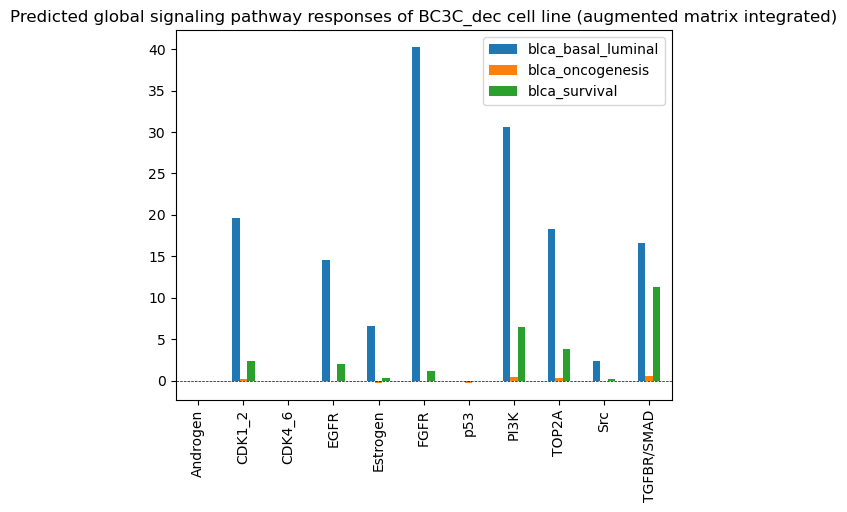

In [19]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line (augmented matrix integrated)")

In [23]:
display(rm_filt)
rm_subset=rm_filt[['Androgen','CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'PI3K', 'p53', 'TOP2A','Src','TGFBR/SMAD']]

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFBR/SMAD,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.0,-0.036271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.0,0.148730,0.000000,0.191798,0.252971,0.000000,0.000000,0.089251,0.000000,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.0,0.000000,0.130940,0.000000,0.000000,0.000000,0.000000,0.000000,-0.155171,0.0,0.0,0.0
EGFR,0.0,0.000000,0.0,-1.000000,0.000000,0.333090,-0.297475,0.000000,0.000000,0.000000,0.547341,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.0,0.000000,-1.000000,0.263969,0.143495,0.000000,0.000000,0.085032,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000000,0.0,0.430344,0.133234,-1.000000,0.148521,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
PI3K,0.0,0.355449,0.0,-0.268547,0.000000,0.000000,-1.000000,0.000000,0.597642,0.000000,0.282728,0.0,0.0,0.0
p53,0.0,0.000000,0.0,0.140947,0.000000,0.000000,0.081025,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.0,-0.133274,0.000000,0.000000,0.166169,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.331858,0.0,0.000000,0.528373,0.000000,-0.259721,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0


In [24]:
rm_subset=rm_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]
rm_subset=rm_subset.T
display(rm_subset)

,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000
CDK1_2,8.016145,0.000000,0.000000
CDK4_6,0.000000,0.000000,0.000000
EGFR,0.000000,0.000000,0.000000
Estrogen,0.000000,-0.287235,0.000000
FGFR,29.906385,0.000000,0.000000
PI3K,18.757218,0.384438,4.383326
p53,0.000000,-0.301065,0.000000
TOP2A,0.000000,0.000000,0.000000
Src,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C_dec cell line (augmented matrix integrated)')

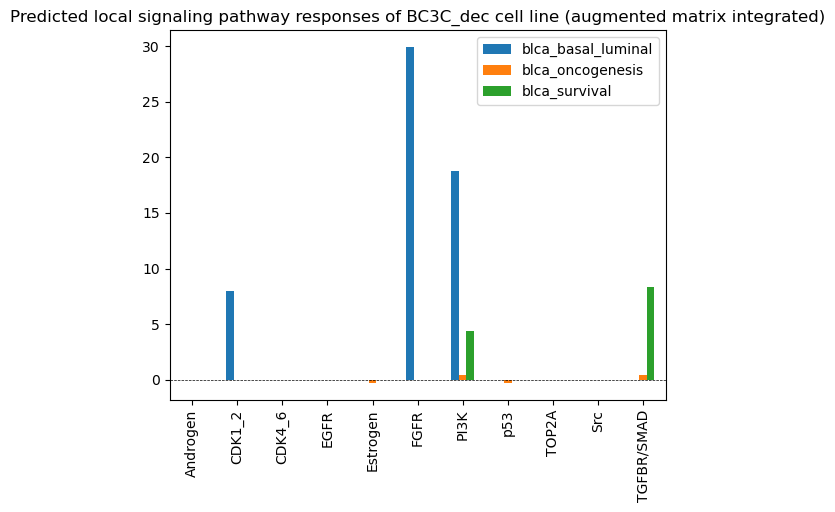

In [25]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line (augmented matrix integrated)")